<a href="https://colab.research.google.com/github/xtianu/CV_Tirana_2026/blob/main/M3_Image%20Classification/Exercise3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MODULE 3: IMAGE CLASSIFICATION

Christian Mata, PhD

# **EXERCISE 3**

Connecting to Google Drive

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


1. Load image

/tmp/ipykernel_20306/3039574059.py:6: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.imshow(image) #prepare Image to show
/tmp/ipykernel_20306/3039574059.py:7: FutureWarning: `show` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  sk.io.show()  #show rendered images


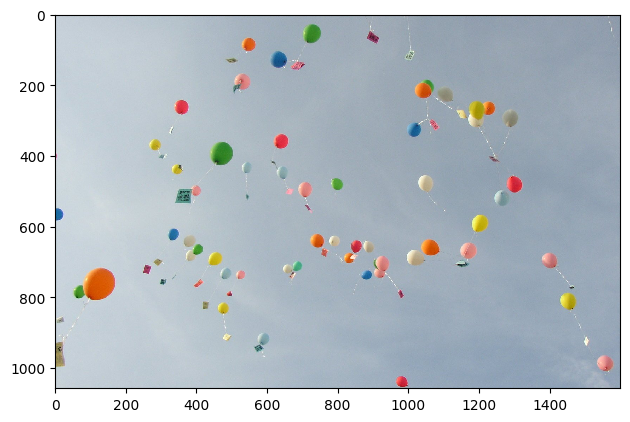

In [21]:
import skimage as sk
from skimage.io import imread

image = sk.io.imread('/content/drive/MyDrive/UT/TiranaCV2025/images/baloons.jpg') #read image saves an NumpyArray with pixels

sk.io.imshow(image) #prepare Image to show
sk.io.show()  #show rendered images

2.Convert from RGB to grayscale

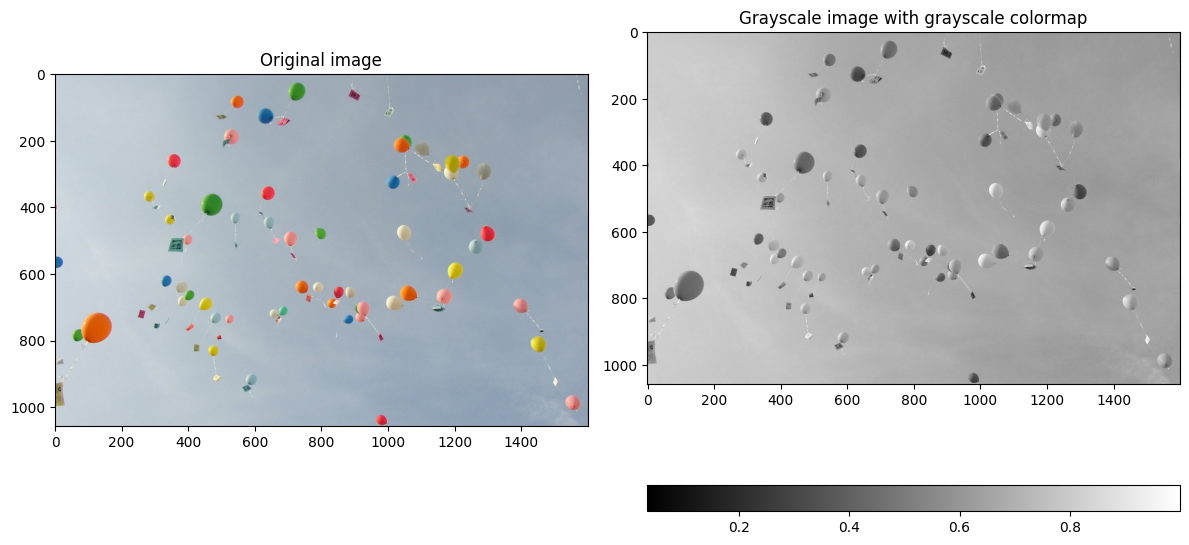

In [22]:
from skimage import data
from skimage.color import rgb2gray
import matplotlib.pyplot as plt


I_GrayScale = rgb2gray(image)

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
ax = axes.ravel()

ax[0].imshow(image)
ax[0].set_title("Original image")

im = ax[1].imshow(I_GrayScale, cmap=plt.cm.gray)
ax[1].set_title("Grayscale image with grayscale colormap")
fig.colorbar(im, ax=ax[1], orientation="horizontal")

plt.tight_layout()
plt.show()

3. Gamma correction with $\gamma=0.5$

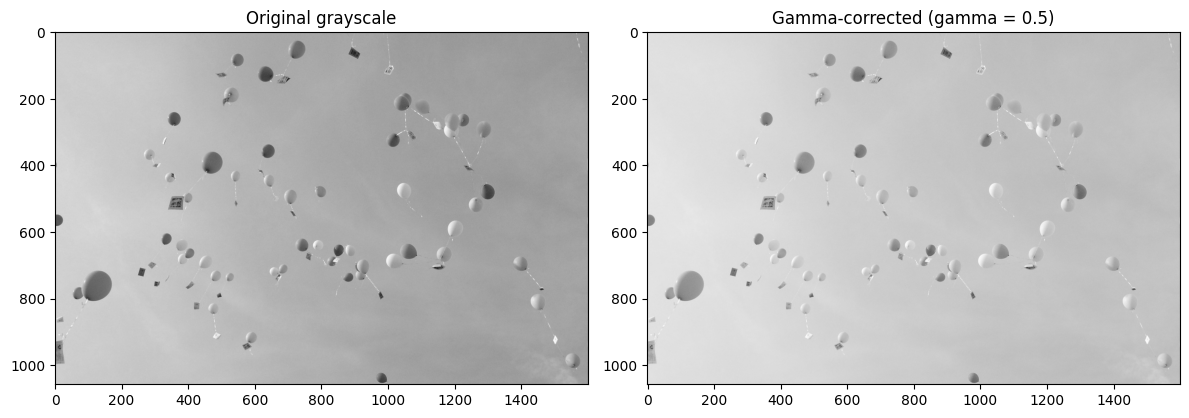

In [23]:
from skimage import data, exposure
from skimage.color import rgb2gray
import matplotlib.pyplot as plt

I_GrayScale = rgb2gray(image)

I_gamma_corrected = exposure.adjust_gamma(I_GrayScale, 0.5)

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
ax = axes.ravel()

ax[0].imshow(I_GrayScale, cmap='gray')
ax[0].set_title("Original grayscale")

ax[1].imshow(I_gamma_corrected, cmap='gray')
ax[1].set_title("Gamma-corrected (gamma = 0.5)")

plt.tight_layout()
plt.show()

4. Otsu threshold from grayscale (non gamma corrected)

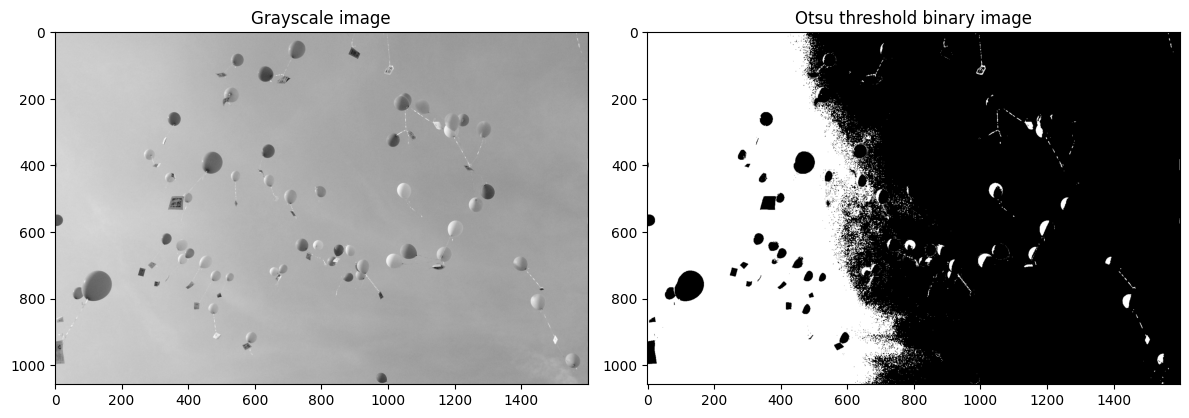

In [24]:
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

I_GrayScale = rgb2gray(image)

threshold = threshold_otsu(I_GrayScale)
binary_image = I_GrayScale > threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 7))
ax = axes.ravel()

ax[0].imshow(I_GrayScale, cmap='gray')
ax[0].set_title("Grayscale image")

ax[1].imshow(binary_image, cmap='gray')
ax[1].set_title("Otsu threshold binary image")

plt.tight_layout()
plt.show()

5. Apply Otsu's threhold to gamma-corrected image

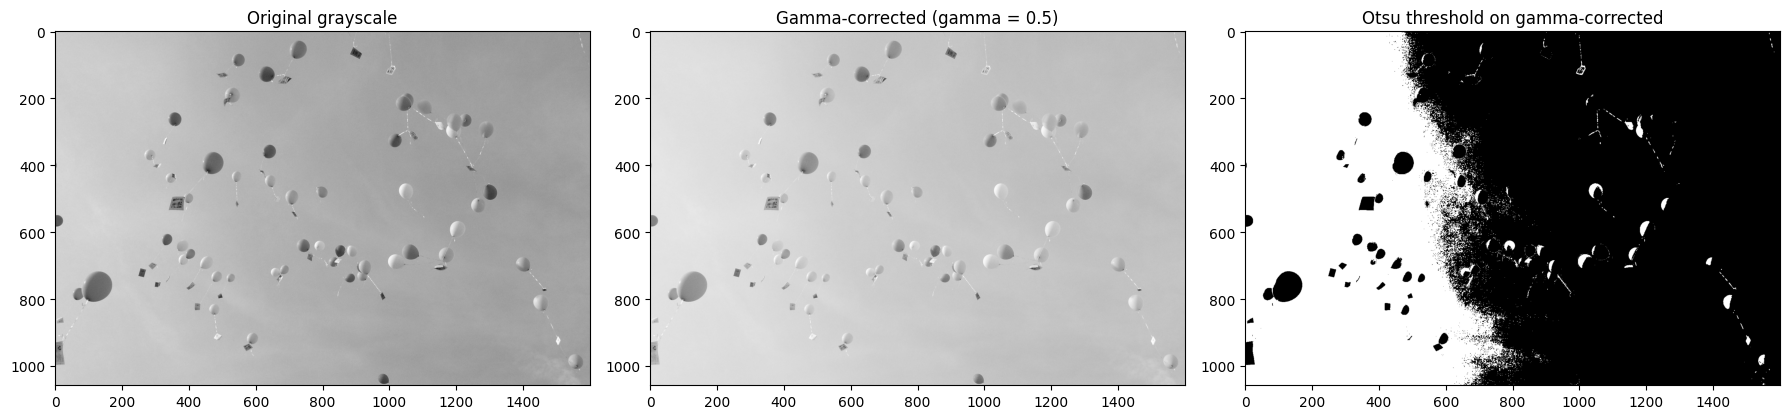

In [25]:
from skimage import data, exposure
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

I_GrayScale = rgb2gray(image)
I_gamma = exposure.adjust_gamma(I_GrayScale, 0.5)

threshold = threshold_otsu(I_gamma)
binary_image = I_gamma > threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 7))
ax = axes.ravel()

ax[0].imshow(I_GrayScale, cmap='gray')
ax[0].set_title("Original grayscale")

ax[1].imshow(I_gamma, cmap='gray')
ax[1].set_title("Gamma-corrected (gamma = 0.5)")

ax[2].imshow(binary_image, cmap='gray')
ax[2].set_title("Otsu threshold on gamma-corrected")

plt.tight_layout()
plt.show()

6. label the objects

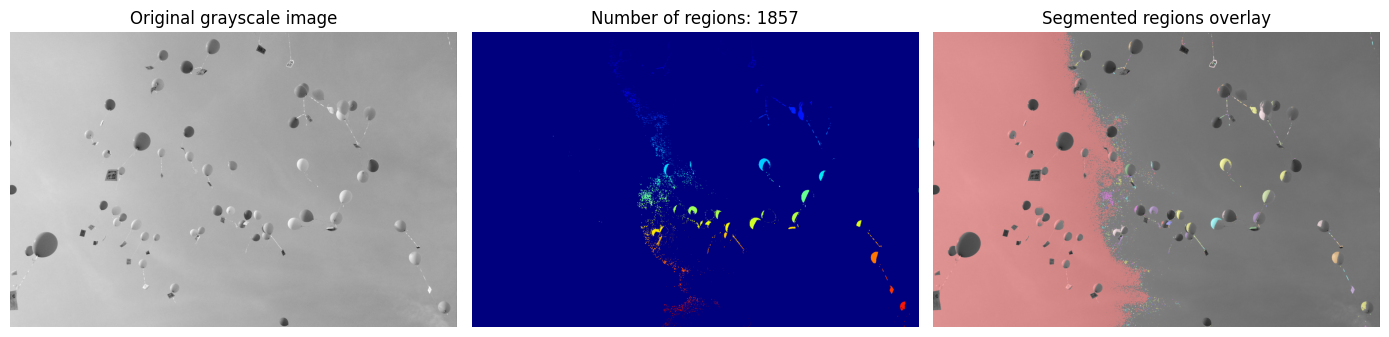

In [26]:
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label
from skimage.color import label2rgb
import matplotlib.pyplot as plt

IG = rgb2gray(image)

thresh = threshold_otsu(IG)
bw = IG > thresh

label_image, nregions = label(bw, return_num=True)
image_label_overlay = label2rgb(label_image, image=IG)

fig, axes = plt.subplots(1, 3, figsize=(14, 9))
ax = axes.ravel()

ax[0].imshow(IG, cmap=plt.cm.gray)
ax[0].set_title('Original grayscale image')

ax[1].imshow(label_image, cmap=plt.cm.jet)
ax[1].set_title('Number of regions: {}'.format(nregions))

ax[2].imshow(image_label_overlay, cmap=plt.cm.jet)
ax[2].set_title('Segmented regions overlay')

ax[0].set_axis_off()
ax[1].set_axis_off()
ax[2].set_axis_off()

plt.tight_layout()
plt.show()

7. Extract regional properties (Area and eccentricity)

In [28]:
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

IG = rgb2gray(image)

thresh = threshold_otsu(IG)
bw = IG > thresh

label_image, nregions = label(bw, return_num=True)

props = regionprops(label_image)

print("All regions and their properties:")
for ireg in range(0, nregions):
    print('Region {}: Area = {} pixels, Eccentricity = {:.4f}'.format(
        ireg+1, props[ireg].area, props[ireg].eccentricity))

# Identify regions that meet the 'balloon' criteria
balloon_regions = []
for ireg in range(nregions):
    if props[ireg].area > 500 and props[ireg].eccentricity < 0.8:
        balloon_regions.append(ireg + 1)

print("\nRegions identified as 'balloons' (Area > 500 and Eccentricity < 0.8):")
if balloon_regions:
    for reg_id in balloon_regions:
        print(f"Region {reg_id}: Area = {props[reg_id-1].area} pixels, Eccentricity = {props[reg_id-1].eccentricity:.4f}")
    print(f"Total balloons detected: {len(balloon_regions)}")
else:
    print("No regions met the criteria for balloons.")

Region 1: Area = 617493.0 pixels, Eccentricity = 0.8139
Region 2: Area = 6.0 pixels, Eccentricity = 0.7906
Region 3: Area = 6.0 pixels, Eccentricity = 0.9747
Region 4: Area = 2.0 pixels, Eccentricity = 1.0000
Region 5: Area = 8.0 pixels, Eccentricity = 0.9186
Region 6: Area = 3.0 pixels, Eccentricity = 0.9737
Region 7: Area = 2.0 pixels, Eccentricity = 1.0000
Region 8: Area = 1.0 pixels, Eccentricity = 0.0000
Region 9: Area = 4.0 pixels, Eccentricity = 0.9129
Region 10: Area = 4.0 pixels, Eccentricity = 1.0000
Region 11: Area = 5.0 pixels, Eccentricity = 0.8165
Region 12: Area = 1.0 pixels, Eccentricity = 0.0000
Region 13: Area = 7.0 pixels, Eccentricity = 0.9349
Region 14: Area = 17.0 pixels, Eccentricity = 0.9644
Region 15: Area = 3.0 pixels, Eccentricity = 1.0000
Region 16: Area = 2.0 pixels, Eccentricity = 1.0000
Region 17: Area = 7.0 pixels, Eccentricity = 0.8887
Region 18: Area = 4.0 pixels, Eccentricity = 0.9129
Region 19: Area = 6.0 pixels, Eccentricity = 0.7906
Region 20: Area

Show the sccaterplot the features

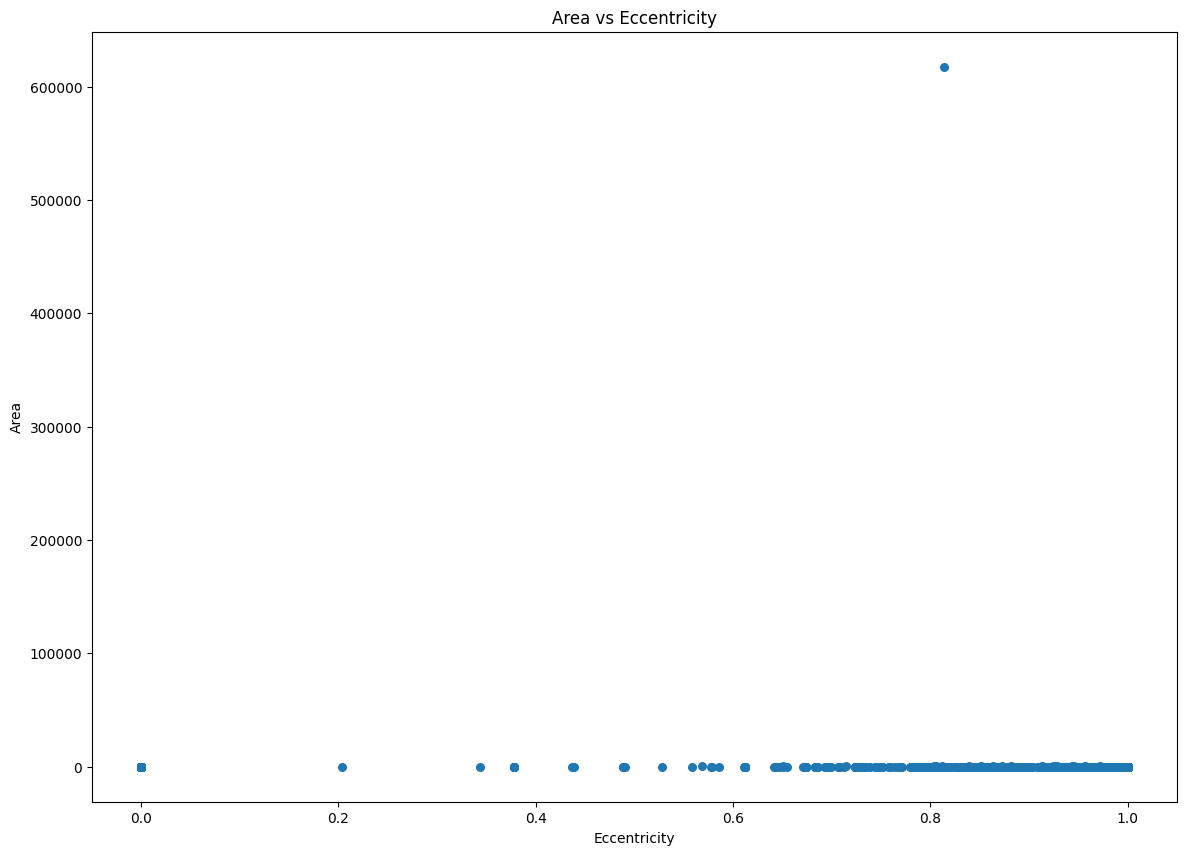

In [29]:
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

IG = rgb2gray(image)

thresh = threshold_otsu(IG)
bw = IG > thresh

label_image, nregions = label(bw, return_num=True)
props = regionprops(label_image)

features = np.zeros((nregions, 2))

for i in range(0, nregions):
    features[i, 0] = props[i].eccentricity
    features[i, 1] = props[i].area

fig = plt.figure(figsize=(14, 10))
plt.scatter(features[:, 0], features[:, 1], s=30, marker='o')
plt.xlabel('Eccentricity')
plt.ylabel('Area')
plt.title('Area vs Eccentricity')
plt.show()

8. Find balloons as objects with area higher than 500 and eccentricity lower than 0.8


In [31]:
from skimage import data
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
from skimage.measure import label, regionprops
import numpy as np
import matplotlib.pyplot as plt

IG = rgb2gray(image)

thresh = threshold_otsu(IG)
bw = IG > thresh

label_image, nregions = label(bw, return_num=True)
props = regionprops(label_image)

features = np.zeros((nregions, 2))

for i in range(0, nregions):
    features[i, 0] = props[i].eccentricity
    features[i, 1] = props[i].area

ind_balloons = np.where((features[:, 1] > 500) & (features[:, 0] < 0.8))
ind_balloon_regions = np.array(ind_balloons) + 1

print('There are {} balloons'.format(len(ind_balloon_regions[0])))
print('Balloon regions: {}'.format(ind_balloon_regions))

There are 3 balloons
Balloon regions: [[ 603  874 1006]]


9. Plot the baloons

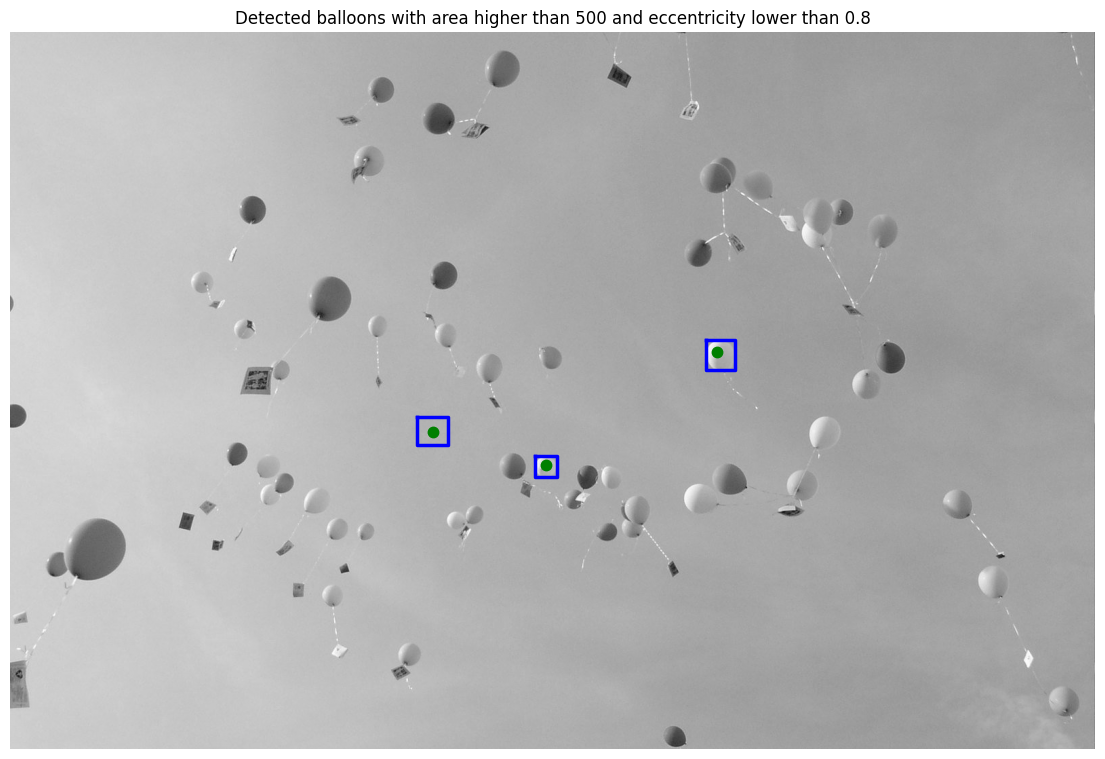

In [33]:
ind_balloons = np.where((features[:, 1] > 500) & (features[:, 0] < 0.8))

fig, ax = plt.subplots(figsize=(14, 10))
ax.imshow(IG, cmap=plt.cm.gray)

for i in np.squeeze(ind_balloons):
    p = props[i]
    y0, x0 = p.centroid
    ax.plot(x0, y0, '.g', markersize=15)

    minr, minc, maxr, maxc = p.bbox
    bx = (minc, maxc, maxc, minc, minc)
    by = (minr, minr, maxr, maxr, minr)
    ax.plot(bx, by, '-b', linewidth=2.5)

ax.set_axis_off()
plt.title('Detected balloons with area higher than 500 and eccentricity lower than 0.8')
plt.show()